In [315]:
import os
import pandas as pd
import geopandas as gpd
import rasterio
import re
import numpy as np
import matplotlib.pyplot as plt

In [316]:
# user-defined paths
base_dir = '../../../../datos-notebooks/3.global-data-cba/'
ground_data_name = 'ground_data_170226_shadow_sun.csv'

In [317]:
# derived paths
ground_data_path = os.path.join(base_dir, 'MRT-prediction/ground_data', ground_data_name)

#### reading file

In [318]:
df = pd.read_csv(ground_data_path, sep=",")

#### correcting t1 values
T1_corr = 0.628 * TG1 + 9.732 from notebook 3.4.4.2.

TG1: Old thermometer (Sper Scientific 800036)

TG2: new thermometer (TM-188D TENMARS )

In [319]:
# Create corrected TG column based on instrument type
df["tg_corr"] = np.where(
    df["instrument (1 viejo 2 nuevo)"] == 1,
    0.628 * df["TG"] + 9.732,   # apply correction for old instrument
    df["TG"]                   # keep original value for new instrument
)

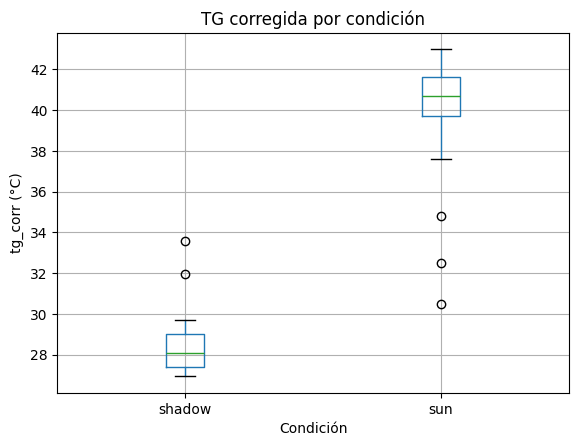

In [320]:
import matplotlib.pyplot as plt

# Boxplot of corrected TG by condition
df.boxplot(column="tg_corr", by="condition")

plt.title("TG corregida por condición")
plt.suptitle("")  # remove automatic subtitle
plt.xlabel("Condición")
plt.ylabel("tg_corr (°C)")
plt.show()

In [321]:
import plotly.express as px
import pandas as pd

# Convert time to datetime
df["time"] = pd.to_datetime(df["time"], format="%H:%M")

fig = px.scatter(
    df,
    x="time",
    y="tg_corr",
    color="condition",
    color_discrete_map={
        "sun": "orange",
        "shadow": "blue"
    },
    hover_data=["TG", "tg_corr", "wind"],
    title="TG in time (corrected)"
)

fig.show()

MRT

In [322]:
# Fill NaN values
df["TA (t)"] = df["TA (t)"].fillna(29.5)
df["wind"] = df["wind"].fillna(0.00)

# Wind was t+measured with 2nd anemometer (big one) - corrections are made based on notebook 3.4.4.4.
# Subtract 0.88 for wind extracted with anemometer 2 (grande)
df["wind_corr"] = df["wind"] - 0.88
df["wind_corr"] = np.where(df["wind_corr"] < 0, 0, df["wind_corr"])

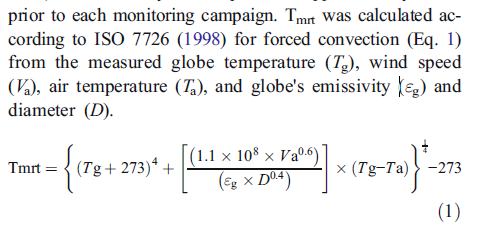

In [323]:
# Parameters
eps = 0.95
D1 = 0.04   # diameter of globe 1 [m] 
D2 = 0.05  # diameter of globe 2 [m] 

# Select diameter according to instrument
D = np.where(df["instrument (1 viejo 2 nuevo)"] == 1, D1,D2)

# MRT calculation using row-specific diameter
# wind used close to 0 for all cases because values were introducing errors and the changes are not significant (all under 1 m/s)
df["MRT"] = (
    (
        (df["tg_corr"] + 273.15)**4
        + (1.1e8 * 0.01 **0.6 / (eps * D**0.4)) * (df["tg_corr"] - df["TA (t)"]) 
    )**0.25
    - 273.15
)

In [324]:
import plotly.express as px
import pandas as pd


fig = px.scatter(
    df,
    x="time",
    y="MRT",
    color="condition",
    color_discrete_map={
        "sun": "orange",
        "shadow": "blue"
    },
    hover_data=["TG", "MRT", "wind"],
    title="MRT in time "
)

fig.show()

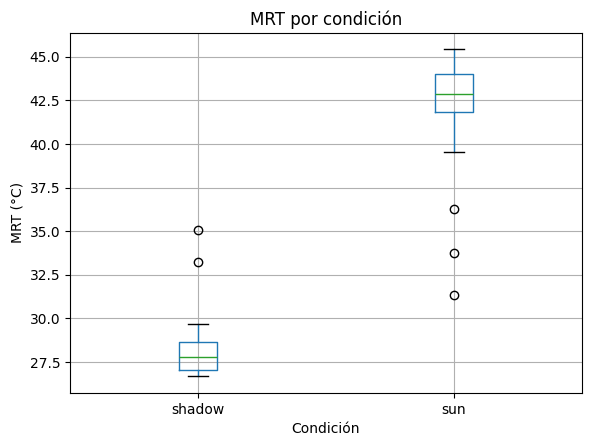

In [325]:
import matplotlib.pyplot as plt

# Boxplot of corrected MRT by condition
df.boxplot(column="MRT", by="condition")

plt.title("MRT por condición")
plt.suptitle("")  # remove automatic subtitle
plt.xlabel("Condición")
plt.ylabel("MRT (°C)")
plt.show()


In [326]:
df_filtrado = df[df["time"] >= pd.to_datetime("12:09", format="%H:%M")]

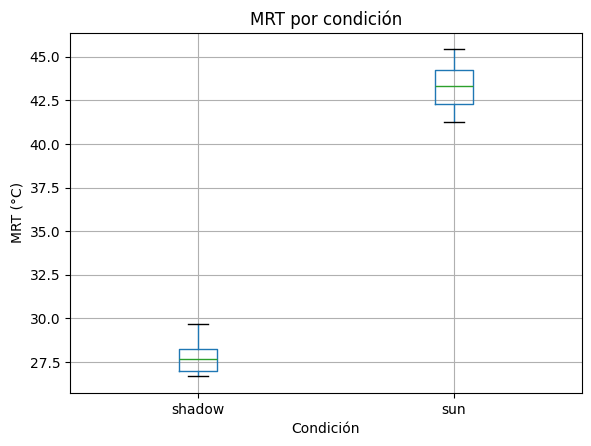

In [327]:
# Boxplot of corrected and filtered MRT by condition
df_filtrado.boxplot(column="MRT", by="condition")

plt.title("MRT por condición")
plt.suptitle("")  # remove automatic subtitle
plt.xlabel("Condición")
plt.ylabel("MRT (°C)")
plt.show()

In [328]:
# Compute mean by condition
means = df_filtrado.groupby("condition")["MRT"].mean()

# Difference sun - shadow
diff = means["sun"] - means["shadow"]
diff = round(diff, 2)

means, diff

(condition
 shadow    27.752233
 sun       43.283782
 Name: MRT, dtype: float64,
 np.float64(15.53))

In [329]:
from scipy.stats import ttest_ind

sun = df_filtrado[df_filtrado["condition"] == "sun"]["MRT"]
shadow = df_filtrado[df_filtrado["condition"] == "shadow"]["MRT"]

ttest_ind(sun, shadow, equal_var=False)  # Welch t-test

TtestResult(statistic=np.float64(41.74033059231161), pvalue=np.float64(1.1075789748864718e-28), df=np.float64(30.809941144133305))

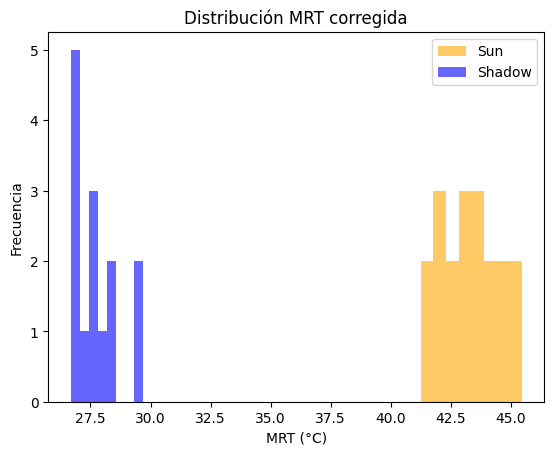

In [330]:
import matplotlib.pyplot as plt

sun = df_filtrado[df_filtrado["condition"] == "sun"]["MRT"]
shadow = df_filtrado[df_filtrado["condition"] == "shadow"]["MRT"]

plt.hist(sun, bins=8, alpha=0.6, label="Sun", color="orange")
plt.hist(shadow, bins=8, alpha=0.6, label="Shadow", color="blue")

plt.xlabel("MRT (°C)")
plt.ylabel("Frecuencia")
plt.title("Distribución MRT corregida")
plt.legend()
plt.show()